In [2]:
# Pick the best clustering set

rm(list=ls())

library(dplyr)
library(ConsensusClusterPlus)
library(tibble)
library(survival)
library(survminer)


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


Loading required package: ggplot2

Loading required package: ggpubr


Attaching package: ‘survminer’


The following object is masked from ‘package:survival’:

    myeloma




In [3]:
load("../data/tcga_time_deconv_quantiseq.RData")
# Data included: res.deconv.epic, df.clinical.bcr, prad.gene, time.epic.bcr

In [4]:
# Pick the (best) deconv set
res.deconv <- res.deconv.quantiseq

In [5]:
# Scale: z-score transformation --- 0 mean 1 deviation
res.deconv.scale <- t(scale(t(res.deconv)))

In [6]:
# Clustering
results.tcga <- ConsensusClusterPlus(res.deconv.scale, maxK=6, reps=1000, pItem=0.8, pFeature=1, title="../output/Consensus_clustering_quantiseq_pam_pearson_average_tcga", 
                                     clusterAlg="pam", distance="pearson", seed=123456, plot="pdf")

end fraction

clustered

clustered

clustered

clustered

clustered



In [7]:
res.deconv.sample <- as.data.frame(t(res.deconv.scale))

In [8]:
# add "bcr_months" column
df.clinical.bcr$bcr_months <- df.clinical.bcr$bcr_days/30

In [9]:
# ======== Survival analysis with 3 clusters =============
cluster <- unname(results.tcga[[3]][["consensusClass"]])

cluster[which(cluster == "1")] <- "good"
cluster[which(cluster == "2")] <- "mediate"
cluster[which(cluster == "3")] <- "bad"

cluster <- factor(cluster, levels = c("good", "mediate", "bad"))

In [10]:
change_cluster_name <- function(old.names, old.levels = c("good", "mediate", "bad"), new.levels = c("TCE", "TuCE", "TASCE")) {
  new.names <- as.character(old.names)
  
  for (i in seq(1, length(old.levels))){
    new.names[which(new.names == old.levels[i])] <- new.levels[i]
  }
  
  new.names <- factor(new.names, levels = new.levels)
  
  return(new.names)
}

In [11]:
new.levels <- c("TCE", "EPCE", "TASCE")

cluster <- change_cluster_name(cluster, old.levels = c("good", "mediate", "bad"), new.levels)

res.deconv.sample$cluster <- cluster

In [12]:
df.clinical.bcr.cluster <- merge(df.clinical.bcr, res.deconv.sample, by = "row.names")
df.clinical.bcr.cluster <- column_to_rownames(df.clinical.bcr.cluster, colnames(df.clinical.bcr.cluster)[1])

df.clinical.bcr.cluster$bcr_months <- as.numeric(df.clinical.bcr.cluster$bcr_months)
df.clinical.bcr.cluster$biochemical_recurrence <- 1*(df.clinical.bcr.cluster$biochemical_recurrence=="YES")

In [13]:
# draw the Surv curve of TCGA's 3 clusters
# options(repr.plot.width=6, repr.plot.height=5.5)

# load color palette
source("color_palette.R")

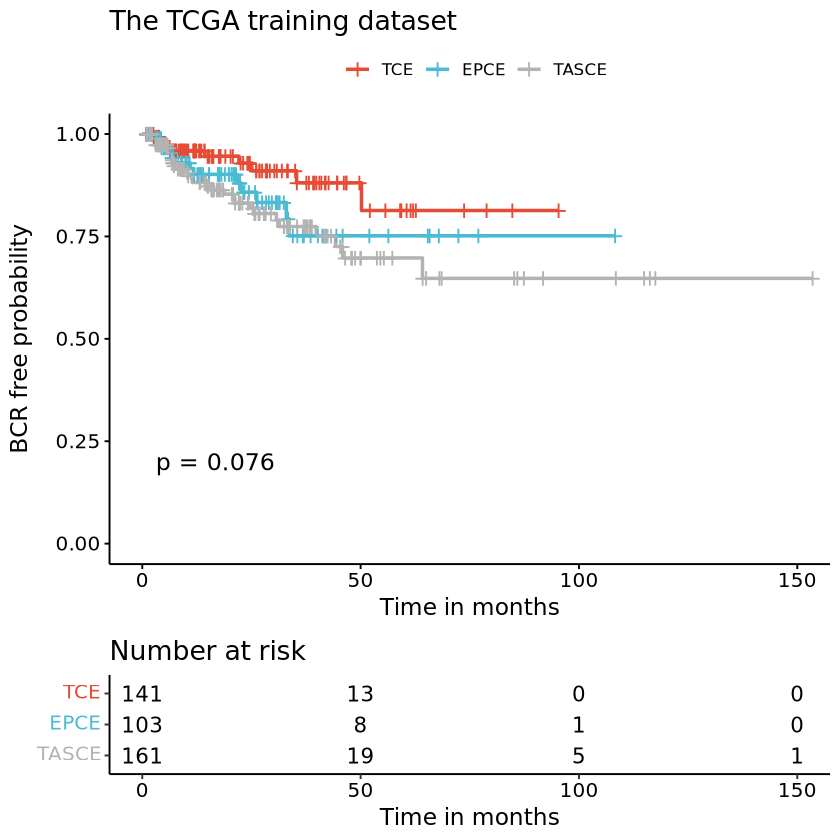

In [14]:
km.fit <- survminer::surv_fit(Surv(bcr_months, biochemical_recurrence) ~ cluster, data=df.clinical.bcr.cluster)
p.surv <- survminer::ggsurvplot(km.fit, pval = TRUE, risk.table = TRUE, ncensor.plot = FALSE,
                                title = "The TCGA training dataset",
                                palette = color.three.clusters,
                                legend.title = "", legend.labs = c("TCE", "EPCE", "TASCE"),
                                xlab = "Time in months", ylab = "BCR free probability")
print(p.surv)

In [15]:
res.deconv.tcga <- res.deconv
res.deconv.scale.tcga <- res.deconv.scale
res.deconv.sample.tcga <- res.deconv.sample

In [16]:
patients.outlier <- rownames(df.clinical.bcr.cluster %>% filter(cluster == new.levels[1] & biochemical_recurrence == "1" & bcr_days > 1000))
print(patients.outlier)

[1] "TCGA.KK.A8IC" "TCGA.YL.A9WX"


In [17]:
df.clinical.bcr.cluster <- df.clinical.bcr.cluster[!(rownames(df.clinical.bcr.cluster) %in% patients.outlier), ]

patients.keep <- rownames(df.clinical.bcr.cluster)

# update the other variables' patients
res.deconv.tcga <- res.deconv.tcga[, patients.keep]
res.deconv.scale.tcga <- res.deconv.scale.tcga[, patients.keep]
res.deconv.sample.tcga <- res.deconv.sample.tcga[patients.keep, ]

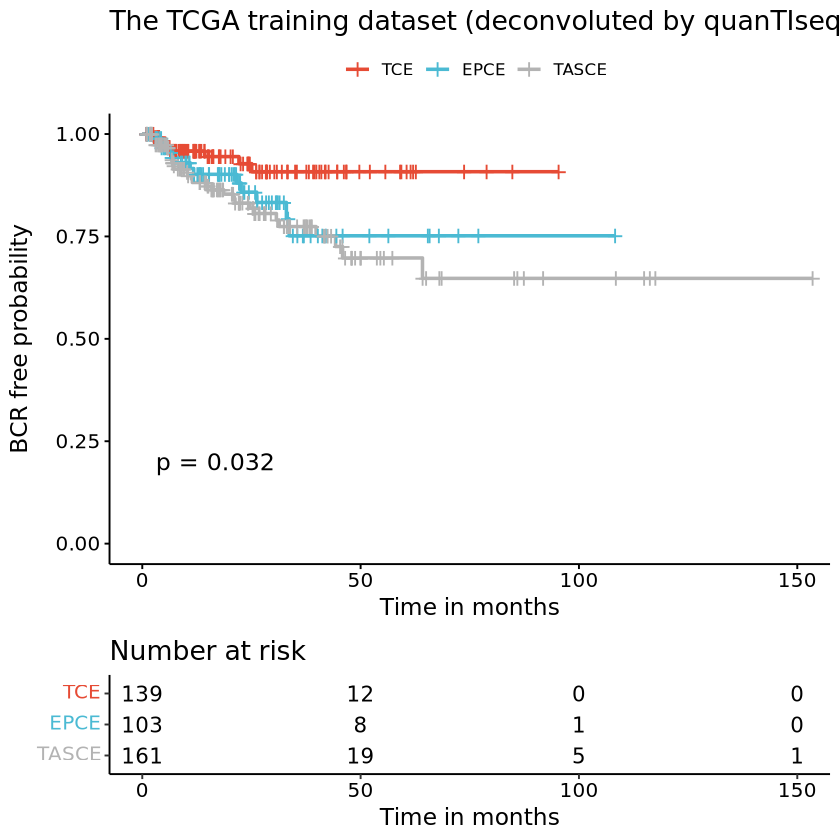

In [18]:
km.fit <- survminer::surv_fit(Surv(bcr_months, biochemical_recurrence) ~ cluster, data=df.clinical.bcr.cluster)
p.surv <- survminer::ggsurvplot(km.fit, pval = TRUE, risk.table = TRUE, ncensor.plot = FALSE,
                                title = "The TCGA training dataset (deconvoluted by quanTIseq",
                                palette = color.three.clusters,
                                legend.title = "", legend.labs = c("TCE", "EPCE", "TASCE"),
                                xlab = "Time in months", ylab = "BCR free probability")
print(p.surv)

In [20]:
# save the data
save(res.deconv.tcga, res.deconv.scale.tcga, res.deconv.sample.tcga, df.clinical.bcr.cluster, file = "../data/clustering_tcga_removing_badguys_quantiseq.RData")